In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib
import pandas as pd
import mne 
import os
from mne.preprocessing import ICA
from scipy.stats import pearsonr
import seaborn as sns
import sys
sys.path.append(os.path.abspath('..'))
from utils import identify_bad_channels,remove_epochs_with_bad_mmn_channels, Average_in_trials_in_time_window,remove_or_interpolate_epochs_with_n_bad_chn

In [2]:
subject_info= pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\Participant_details.xlsx")
subject_info.head()

,participant_id,age,is_controlled_block,gender,profession,b1_deviant,b2_deviant,b3_deviant
0,sd011,30,N,M,PG_acd,PN,BT,NaN
1,sd012,25,N,M,PG_acd,PN,BT,NaN
2,sd013,25,N,M,PG_acd,PN,BT,NaN
3,sd014,28,N,M,PG_acd,PN,BT,NaN
4,sd015,31,N,M,PG_acd,PN,BT,NaN


# Combined Block 1 and 2 results

In [3]:
import mne

mne.set_log_level('WARNING')  # Options: 'DEBUG', 'INFO', 'WARNING', 'ERROR', 'CRITICAL'


In [4]:

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/"
subjects = [sub for sub in os.listdir(data_folder) if (("sub-" in sub) & (os.path.isdir(os.path.join(data_folder,sub))))]
print(subjects)
data_type = "eeg"
 # it is useful to scroll eeg data 
B1_MMN_erp_evoked_dict  = {}
B1_devi_eps_evoked_dict  = {}
B1_sta_eps_evoked_dict  = {}
B2_devi_eps_evoked_dict = {}
B2_sta_eps_evoked_dict = {}
B2_MMN_erp_evoked_dict = {}
epoch_per_num = {}
epoch_per_num["subject Dropped"] = []
for sub in subjects:
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        print(sub)
        if eeg[-5:] == ".vhdr":
            if   sub   in  ['sub-sd058']:
                continue
               
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            print(os.path.join(path,eeg))
            #raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            raw.resample(512)
            # filter 
            raw.filter(l_freq=0.1,h_freq=30  )
            #ICA 
            ica = ICA(n_components=20, random_state=97,max_iter=500)
            ica.fit(raw)
            print("ICA Completed ...")
            #ica.plot_components()
            #removing Eye movement artifacts 
            eog_channels = ['Fp1', 'Fp2',"AF7","AF8",'F7', 'F8']  # Adjust these to match your channel names
            eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
            #print(eog_indices, eog_scores)
            ica.exclude = eog_indices
            ica.apply(raw)
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            events,event_dict = mne.events_from_annotations(raw)
            print(events,event_dict)
            # Create Epochs without droping the eye blink event
            S14= event_dict['Stimulus/S   14']
            S15 = event_dict['Stimulus/S   15']
            S24 = event_dict['Stimulus/S   24']
            S25 = event_dict['Stimulus/S   25']
            epochs = mne.Epochs(raw, events, event_id=[S14,S15,S24,S25],baseline=(None, 0), tmin=-0.300, tmax=0.700, preload=True,event_repeated='merge')
            # Define your MMN channels

            mmn_channels = [ 'Fz', 'Cz','Pz']  #Example MMN channels, adjust as needed
            try:
                epochs.drop_channels(['GSR', 'PPG'])
            except:
                print("NO PPG sensor")
                pass
            cleaned_epochs = remove_or_interpolate_epochs_with_n_bad_chn(epochs,  bad_chn_threshold = 6, amplitude_threshold=75e-6)
            #cleaned_epochs = remove_epochs_with_n_bad_channels(epochs, bad_chn_thresold = 8, amplitude_threshold=80e-6)
            
            if len(cleaned_epochs[str(S14),str(S15)]) < 450 or  len(cleaned_epochs[str(S24),str(S25)]) < 450 :
                epoch_per_num["subject Dropped"].append(sub)  
                print("B1 len :",len(cleaned_epochs[str(S14),str(S15)]),"B2 len :",len(cleaned_epochs[str(S24),str(S25)]))
                continue

            print(f"Original number of epochs: {len(epochs)}")
            print(f"Number of epochs after removal: {len(cleaned_epochs)}")
            epoch_per_num[sub] = len(cleaned_epochs)
            try:
                B1_devi_eps = cleaned_epochs[str(S15)].average()
                B1_sta_eps = cleaned_epochs[str(S14)].average()
                B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])
                evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
            
                B1_devi_eps_evoked_dict[sub] = B1_devi_eps
                B1_sta_eps_evoked_dict[sub] = B1_sta_eps
                B1_MMN_erp_evoked_dict[sub] = B1_MMN_erp
                #mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = str (sub) + " BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")

                # Block 2 

                B2_devi_eps = cleaned_epochs[str(S25)].average()
                B2_sta_eps = cleaned_epochs[str(S24)].average()    
                B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B2_sta_eps], weights=[1,-1])
                evokeds = dict(B2_MMN_erp =B2_MMN_erp, B2_devi_eps= B2_devi_eps,B2_sta_eps=B2_sta_eps)  
            
                B2_devi_eps_evoked_dict[sub] = B2_devi_eps
                B2_sta_eps_evoked_dict[sub] = B2_sta_eps
                B2_MMN_erp_evoked_dict[sub] = B2_MMN_erp
            except:   
                print("ERRor FOr epoching ")    

['sub-sd011', 'sub-sd012', 'sub-sd013', 'sub-sd014', 'sub-sd015', 'sub-sd016', 'sub-sd017', 'sub-sd018', 'sub-sd019', 'sub-sd020', 'sub-sd021', 'sub-sd022', 'sub-sd023', 'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd027', 'sub-sd028', 'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd032', 'sub-sd033', 'sub-sd034', 'sub-sd035', 'sub-sd036', 'sub-sd037', 'sub-sd038', 'sub-sd039', 'sub-sd040', 'sub-sd041', 'sub-sd042', 'sub-sd043', 'sub-sd044', 'sub-sd045', 'sub-sd046', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd050', 'sub-sd051', 'sub-sd052', 'sub-sd053', 'sub-sd054', 'sub-sd055', 'sub-sd056', 'sub-sd057', 'sub-sd058', 'sub-sd059', 'sub-sd060', 'sub-sd061', 'sub-sd062', 'sub-sd063', 'sub-sd064', 'sub-sd065', 'sub-sd066', 'sub-sd067']
sub-sd011
sub-sd011
sub-sd011
sub-sd011
sub-sd011
sub-sd011
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd011\eeg\sub-sd011_task-auditoryoddball_eeg.vhdr


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1241584       0   10007]
 [1242608       0   10006]
 [1242608       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1411
sub-sd011
sub-sd011
sub-sd011
sub-sd012
sub-sd012
sub-sd012
sub-sd012
sub-sd012
sub-sd012
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd012\eeg\sub-sd012_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1215246       0   10007]
 [1216226       0   10006]
 [1216226       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1684
sub-sd012
sub-sd012
sub-sd012
sub-sd013
sub-sd013
sub-sd013
sub-sd013
sub-sd013
sub-sd013
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd013\eeg\sub-sd013_task-auditoryoddball_eeg.vhdr


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1244906       0   10007]
 [1245563       0   10008]
 [1245563       0   10008]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1723
sub-sd013
sub-sd013
sub-sd013
sub-sd014
sub-sd014
sub-sd014
sub-sd014
sub-sd014
sub-sd014
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd014\eeg\sub-sd014_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1207734       0   10007]
 [1208741       0   10006]
 [1208741       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


B1 len : 221 B2 len : 279
sub-sd014
sub-sd014
sub-sd014
sub-sd015
sub-sd015
sub-sd015
sub-sd015
sub-sd015
sub-sd015
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd015\eeg\sub-sd015_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1208269       0   10007]
 [1209268       0   10006]
 [1209268       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1759
sub-sd015
sub-sd015
sub-sd015
sub-sd016
sub-sd016
sub-sd016
sub-sd016
sub-sd016
sub-sd016
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd016\eeg\sub-sd016_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1204692       0   10007]
 [1205708       0   10006]
 [1205708       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1792
sub-sd016
sub-sd016
sub-sd016
sub-sd017
sub-sd017
sub-sd017
sub-sd017
sub-sd017
sub-sd017
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd017\eeg\sub-sd017_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10009]
 [      0       0   10008]
 [      0       0   10009]
 ...
 [1164176       0   10007]
 [1164825       0   10006]
 [1164825       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   24': 10006, 'Stimulus/S   25': 10007, 'Stimulus/S10001': 10008, 'Stimulus/S99999': 10009}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1742
Number of epochs after removal: 1601
sub-sd017
sub-sd017
sub-sd017
sub-sd018
sub-sd018
sub-sd018
sub-sd018
sub-sd018
sub-sd018
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd018\eeg\sub-sd018_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1233538       0   10007]
 [1234536       0   10006]
 [1234536       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1667
sub-sd018
sub-sd018
sub-sd018
sub-sd019
sub-sd019
sub-sd019
sub-sd019
sub-sd019
sub-sd019
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd019\eeg\sub-sd019_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1204510       0   10007]
 [1205534       0   10006]
 [1205534       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1080
sub-sd019
sub-sd019
sub-sd019
sub-sd020
sub-sd020
sub-sd020
sub-sd020
sub-sd020
sub-sd020
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd020\eeg\sub-sd020_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10011]
 [      0       0   10010]
 [      0       0   10011]
 ...
 [1295911       0   10007]
 [1296919       0   10006]
 [1296919       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S  255': 10009, 'Stimulus/S10001': 10010, 'Stimulus/S99999': 10011}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1772
sub-sd020
sub-sd020
sub-sd020
sub-sd021
sub-sd021
sub-sd021
sub-sd021
sub-sd021
sub-sd021
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd021\eeg\sub-sd021_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10010]
 [     20       0   10009]
 ...
 [1234315       0   10008]
 [1235313       0   10006]
 [1235313       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1548
sub-sd021
sub-sd021
sub-sd021
sub-sd022
sub-sd022
sub-sd022
sub-sd022
sub-sd022
sub-sd022
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd022\eeg\sub-sd022_task-auditoryoddball_eeg.vhdr


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\3596320155.py:36: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (3.9e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 4
  ica.fit(raw)


ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1204610       0   10007]
 [1205608       0   10006]
 [1205608       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1766
sub-sd022
sub-sd022
sub-sd022
sub-sd023
sub-sd023
sub-sd023
sub-sd023
sub-sd023
sub-sd023
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd023\eeg\sub-sd023_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1222632       0   10007]
 [1223647       0   10006]
 [1223647       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1326
sub-sd023
sub-sd023
sub-sd023
sub-sd024
sub-sd024
sub-sd024
sub-sd024
sub-sd024
sub-sd024
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd024\eeg\sub-sd024_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10010]
 [     10       0   10009]
 ...
 [1209103       0   10007]
 [1210101       0   10006]
 [1210101       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1740
sub-sd024
sub-sd024
sub-sd024
sub-sd025
sub-sd025
sub-sd025
sub-sd025
sub-sd025
sub-sd025
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd025\eeg\sub-sd025_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1211543       0   10007]
 [1212550       0   10006]
 [1212550       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1753
sub-sd025
sub-sd025
sub-sd025
sub-sd026
sub-sd026
sub-sd026
sub-sd026
sub-sd026
sub-sd026
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd026\eeg\sub-sd026_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1209594       0   10007]
 [1210277       0   10007]
 [1210277       0   10007]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1532
sub-sd026
sub-sd026
sub-sd026
sub-sd027
sub-sd027
sub-sd027
sub-sd027
sub-sd027
sub-sd027
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd027\eeg\sub-sd027_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1204762       0   10007]
 [1205751       0   10006]
 [1205751       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1747
sub-sd027
sub-sd027
sub-sd027
sub-sd028
sub-sd028
sub-sd028
sub-sd028
sub-sd028
sub-sd028
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd028\eeg\sub-sd028_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1201336       0   10008]
 [1201976       0   10007]
 [1201976       0   10007]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1739
sub-sd028
sub-sd028
sub-sd028
sub-sd029
sub-sd029
sub-sd029
sub-sd029
sub-sd029
sub-sd029
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd029\eeg\sub-sd029_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1206981       0   10008]
 [1208005       0   10006]
 [1208005       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1760
sub-sd029
sub-sd029
sub-sd029
sub-sd030
sub-sd030
sub-sd030
sub-sd030
sub-sd030
sub-sd030
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd030\eeg\sub-sd030_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1240742       0   10007]
 [1241740       0   10006]
 [1241740       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1793
sub-sd030
sub-sd030
sub-sd030
sub-sd031
sub-sd031
sub-sd031
sub-sd031
sub-sd031
sub-sd031
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd031\eeg\sub-sd031_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1211909       0   10007]
 [1212933       0   10006]
 [1212933       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1765
sub-sd031
sub-sd031
sub-sd031
sub-sd032
sub-sd032
sub-sd032
sub-sd032
sub-sd032
sub-sd032
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd032\eeg\sub-sd032_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10011]
 [      0       0   10011]
 [     10       0   10010]
 ...
 [1242576       0   10007]
 [1243583       0   10006]
 [1243583       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S  255': 10009, 'Stimulus/S10001': 10010, 'Stimulus/S99999': 10011}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1550
sub-sd032
sub-sd032
sub-sd032
sub-sd033
sub-sd033
sub-sd033
sub-sd033
sub-sd033
sub-sd033
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd033\eeg\sub-sd033_task-auditoryoddball_eeg.vhdr


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1208444       0   10007]
 [1209118       0   10008]
 [1209118       0   10008]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1776
sub-sd033
sub-sd033
sub-sd033
sub-sd034
sub-sd034
sub-sd034
sub-sd034
sub-sd034
sub-sd034
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd034\eeg\sub-sd034_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10010]
 [      0       0   10009]
 [      0       0   10010]
 ...
 [1210257       0   10007]
 [1211238       0   10006]
 [1211238       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S10001': 10009, 'Stimulus/S99999': 10010}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1690
sub-sd034
sub-sd034
sub-sd034
sub-sd035
sub-sd035
sub-sd035
sub-sd035
sub-sd035
sub-sd035
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd035\eeg\sub-sd035_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1811101       0   10007]
 [1812090       0   10006]
 [1812090       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1575
sub-sd035
sub-sd035
sub-sd035
sub-sd036
sub-sd036
sub-sd036
sub-sd036
sub-sd036
sub-sd036
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd036\eeg\sub-sd036_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1805891       0   10007]
 [1806898       0   10006]
 [1806898       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1697
sub-sd036
sub-sd036
sub-sd036
sub-sd037
sub-sd037
sub-sd037
sub-sd037
sub-sd037
sub-sd037
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd037\eeg\sub-sd037_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1804857       0   10007]
 [1805830       0   10006]
 [1805830       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1772
sub-sd037
sub-sd037
sub-sd037
sub-sd038
sub-sd038
sub-sd038
sub-sd038
sub-sd038
sub-sd038
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd038\eeg\sub-sd038_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1803906       0   10007]
 [1804878       0   10006]
 [1804878       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1587
sub-sd038
sub-sd038
sub-sd038
sub-sd039
sub-sd039
sub-sd039
sub-sd039
sub-sd039
sub-sd039
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd039\eeg\sub-sd039_task-auditoryoddball_eeg.vhdr


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICA Completed ...
[[      0       0   10013]
 [      0       0   10013]
 [     10       0   10012]
 ...
 [1820855       0   10007]
 [1821871       0   10006]
 [1821871       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1787
sub-sd039
sub-sd039
sub-sd039
sub-sd040
sub-sd040
sub-sd040
sub-sd040
sub-sd040
sub-sd040
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd040\eeg\sub-sd040_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1805933       0   10007]
 [1806948       0   10006]
 [1806948       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1532
sub-sd040
sub-sd040
sub-sd040
sub-sd041
sub-sd041
sub-sd041
sub-sd041
sub-sd041
sub-sd041
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd041\eeg\sub-sd041_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10012]
 [      0       0   10011]
 [      0       0   10012]
 ...
 [1858446       0   10005]
 [1858912       0   10001]
 [1858912       0   10001]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   34': 10009, 'Stimulus/S   35': 10010, 'Stimulus/S10001': 10011, 'Stimulus/S99999': 10012}
NO PPG sensor


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 2700
Number of epochs after removal: 2699
sub-sd041
sub-sd041
sub-sd041
sub-sd042
sub-sd042
sub-sd042
sub-sd042
sub-sd042
sub-sd042
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd042\eeg\sub-sd042_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1811895       0   10007]
 [1812884       0   10006]
 [1812884       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1737
sub-sd042
sub-sd042
sub-sd042
sub-sd043
sub-sd043
sub-sd043
sub-sd043
sub-sd043
sub-sd043
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd043\eeg\sub-sd043_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1806911       0   10007]
 [1807918       0   10006]
 [1807918       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


B1 len : 244 B2 len : 276
sub-sd043
sub-sd043
sub-sd043
sub-sd044
sub-sd044
sub-sd044
sub-sd044
sub-sd044
sub-sd044
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd044\eeg\sub-sd044_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1804174       0   10007]
 [1805181       0   10006]
 [1805181       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1629
sub-sd044
sub-sd044
sub-sd044
sub-sd045
sub-sd045
sub-sd045
sub-sd045
sub-sd045
sub-sd045
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd045\eeg\sub-sd045_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1798718       0   10007]
 [1799742       0   10006]
 [1799742       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1573
sub-sd045
sub-sd045
sub-sd045
sub-sd046
sub-sd046
sub-sd046
sub-sd046
sub-sd046
sub-sd046
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd046\eeg\sub-sd046_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10017]
 [      0       0   10016]
 [      0       0   10017]
 ...
 [1893040       0   10014]
 [1893559       0   10011]
 [1893559       0   10011]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   22': 10007, 'Stimulus/S   23': 10008, 'Stimulus/S   24': 10009, 'Stimulus/S   25': 10010, 'Stimulus/S   31': 10011, 'Stimulus/S   32': 10012, 'Stimulus/S   33': 10013, 'Stimulus/S   34': 10014, 'Stimulus/S   35': 10015, 'Stimulus/S10001': 10016, 'Stimulus/S99999': 10017}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1093
sub-sd046
sub-sd046
sub-sd046
sub-sd047
sub-sd047
sub-sd047
sub-sd047
sub-sd047
sub-sd047
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd047\eeg\sub-sd047_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1809775       0   10007]
 [1810782       0   10006]
 [1810782       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1502
sub-sd047
sub-sd047
sub-sd047
sub-sd048
sub-sd048
sub-sd048
sub-sd048
sub-sd048
sub-sd048
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd048\eeg\sub-sd048_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1818105       0   10007]
 [1819129       0   10006]
 [1819129       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1769
sub-sd048
sub-sd048
sub-sd048
sub-sd049
sub-sd049
sub-sd049
sub-sd049
sub-sd049
sub-sd049
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd049\eeg\sub-sd049_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1836054       0   10007]
 [1837052       0   10006]
 [1837052       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1788
sub-sd049
sub-sd049
sub-sd049
sub-sd050
sub-sd050
sub-sd050
sub-sd050
sub-sd050
sub-sd050
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd050\eeg\sub-sd050_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10013]
 [     10       0   10012]
 ...
 [1846920       0   10005]
 [1847902       0   10004]
 [1847902       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1653
sub-sd050
sub-sd050
sub-sd050
sub-sd051
sub-sd051
sub-sd051
sub-sd051
sub-sd051
sub-sd051
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd051\eeg\sub-sd051_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10013]
 [     10       0   10012]
 ...
 [1800848       0   10006]
 [1801863       0   10004]
 [1801863       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1238
sub-sd051
sub-sd051
sub-sd051
sub-sd052
sub-sd052
sub-sd052
sub-sd052
sub-sd052
sub-sd052
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd052\eeg\sub-sd052_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1813376       0   10005]
 [1814391       0   10004]
 [1814391       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1308
sub-sd052
sub-sd052
sub-sd052
sub-sd053
sub-sd053
sub-sd053
sub-sd053
sub-sd053
sub-sd053
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd053\eeg\sub-sd053_task-auditoryoddball_eeg.vhdr


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1815153       0   10005]
 [1816143       0   10004]
 [1816143       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1586
sub-sd053
sub-sd053
sub-sd053
sub-sd054
sub-sd054
sub-sd054
sub-sd054
sub-sd054
sub-sd054
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd054\eeg\sub-sd054_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1823123       0   10005]
 [1823772       0   10005]
 [1823772       0   10005]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1083
sub-sd054
sub-sd054
sub-sd054
sub-sd055
sub-sd055
sub-sd055
sub-sd055
sub-sd055
sub-sd055
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd055\eeg\sub-sd055_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1819502       0   10005]
 [1820525       0   10004]
 [1820525       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


B1 len : 356 B2 len : 517
sub-sd055
sub-sd055
sub-sd055
sub-sd056
sub-sd056
sub-sd056
sub-sd056
sub-sd056
sub-sd056
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd056\eeg\sub-sd056_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1813522       0   10005]
 [1814495       0   10004]
 [1814495       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1603
sub-sd056
sub-sd056
sub-sd056
sub-sd057
sub-sd057
sub-sd057
sub-sd057
sub-sd057
sub-sd057
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd057\eeg\sub-sd057_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10017]
 [      0       0   10016]
 [      0       0   10017]
 ...
 [1881064       0   10009]
 [1881538       0   10006]
 [1881538       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   12': 10002, 'Stimulus/S   13': 10003, 'Stimulus/S   14': 10004, 'Stimulus/S   15': 10005, 'Stimulus/S   21': 10006, 'Stimulus/S   22': 10007, 'Stimulus/S   23': 10008, 'Stimulus/S   24': 10009, 'Stimulus/S   25': 10010, 'Stimulus/S   31': 10011, 'Stimulus/S   32': 10012, 'Stimulus/S   33': 10013, 'Stimulus/S   34': 10014, 'Stimulus/S   35': 10015, 'Stimulus/S10001': 10016, 'Stimulus/S99999': 10017}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1549
sub-sd057
sub-sd057
sub-sd057
sub-sd058
sub-sd058
sub-sd058
sub-sd058
sub-sd058
sub-sd058
sub-sd058
sub-sd058
sub-sd058
sub-sd059
sub-sd059
sub-sd059
sub-sd059
sub-sd059
sub-sd059
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd059\eeg\sub-sd059_task-auditoryoddball_eeg.vhdr


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\3596320155.py:36: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (5.9e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 17
  ica.fit(raw)


ICA Completed ...
[[      0       0   10013]
 [      0       0   10013]
 [     10       0   10012]
 ...
 [1873061       0   10005]
 [1874051       0   10004]
 [1874051       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1723
sub-sd059
sub-sd059
sub-sd059
sub-sd060
sub-sd060
sub-sd060
sub-sd060
sub-sd060
sub-sd060
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd060\eeg\sub-sd060_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1811187       0   10006]
 [1812186       0   10004]
 [1812186       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1787
sub-sd060
sub-sd060
sub-sd060
sub-sd061
sub-sd061
sub-sd061
sub-sd061
sub-sd061
sub-sd061
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd061\eeg\sub-sd061_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10015]
 [      0       0   10014]
 [      0       0   10015]
 ...
 [1902147       0   10007]
 [1902629       0   10004]
 [1902629       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   22': 10005, 'Stimulus/S   23': 10006, 'Stimulus/S   24': 10007, 'Stimulus/S   25': 10008, 'Stimulus/S   31': 10009, 'Stimulus/S   32': 10010, 'Stimulus/S   33': 10011, 'Stimulus/S   34': 10012, 'Stimulus/S   35': 10013, 'Stimulus/S10001': 10014, 'Stimulus/S99999': 10015}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1874
Number of epochs after removal: 1480
sub-sd061
sub-sd061
sub-sd061
sub-sd062
sub-sd062
sub-sd062
sub-sd062
sub-sd062
sub-sd062
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd062\eeg\sub-sd062_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1809853       0   10005]
 [1810552       0   10005]
 [1810552       0   10005]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1795
sub-sd062
sub-sd062
sub-sd062
sub-sd063
sub-sd063
sub-sd063
sub-sd063
sub-sd063
sub-sd063
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd063\eeg\sub-sd063_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1822813       0   10005]
 [1823820       0   10004]
 [1823820       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1720
sub-sd063
sub-sd063
sub-sd063
sub-sd064
sub-sd064
sub-sd064
sub-sd064
sub-sd064
sub-sd064
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd064\eeg\sub-sd064_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1847109       0   10005]
 [1848090       0   10004]
 [1848090       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1788
sub-sd064
sub-sd064
sub-sd064
sub-sd065
sub-sd065
sub-sd065
sub-sd065
sub-sd065
sub-sd065
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd065\eeg\sub-sd065_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1813945       0   10006]
 [1814961       0   10004]
 [1814961       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1737
sub-sd065
sub-sd065
sub-sd065
sub-sd066
sub-sd066
sub-sd066
sub-sd066
sub-sd066
sub-sd066
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd066\eeg\sub-sd066_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10013]
 [     20       0   10012]
 ...
 [1808159       0   10005]
 [1808842       0   10006]
 [1808842       0   10006]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1716
sub-sd066
sub-sd066
sub-sd066
sub-sd067
sub-sd067
sub-sd067
sub-sd067
sub-sd067
sub-sd067
D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/sub-sd067\eeg\sub-sd067_task-auditoryoddball_eeg.vhdr
ICA Completed ...
[[      0       0   10013]
 [      0       0   10012]
 [      0       0   10013]
 ...
 [1809154       0   10005]
 [1810161       0   10004]
 [1810161       0   10004]] {'Stimulus/S   11': 10001, 'Stimulus/S   14': 10002, 'Stimulus/S   15': 10003, 'Stimulus/S   21': 10004, 'Stimulus/S   24': 10005, 'Stimulus/S   25': 10006, 'Stimulus/S   31': 10007, 'Stimulus/S   32': 10008, 'Stimulus/S   33': 10009, 'Stimulus/S   34': 10010, 'Stimulus/S   35': 10011, 'Stimulus/S10001': 10012, 'Stimulus/S99999': 10013}


e:\ecf-exp2-notif-mmn\analysis\utils.py:160: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
e:\ecf-exp2-notif-mmn\analysis\utils.py:180: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(good_epochs)


Original number of epochs: 1800
Number of epochs after removal: 1699
sub-sd067
sub-sd067
sub-sd067


In [5]:
'sub-sd011'  in [ 'sub-sd011', 'sub-sd012', 'sub-sd013', 'sub-sd014', 'sub-sd015', 'sub-sd016', 'sub-sd017']

True

In [6]:
epoch_per_num

{'subject Dropped': ['sub-sd014', 'sub-sd043', 'sub-sd055'],
 'sub-sd011': 1411,
 'sub-sd012': 1684,
 'sub-sd013': 1723,
 'sub-sd015': 1759,
 'sub-sd016': 1792,
 'sub-sd017': 1601,
 'sub-sd018': 1667,
 'sub-sd019': 1080,
 'sub-sd020': 1772,
 'sub-sd021': 1548,
 'sub-sd022': 1766,
 'sub-sd023': 1326,
 'sub-sd024': 1740,
 'sub-sd025': 1753,
 'sub-sd026': 1532,
 'sub-sd027': 1747,
 'sub-sd028': 1739,
 'sub-sd029': 1760,
 'sub-sd030': 1793,
 'sub-sd031': 1765,
 'sub-sd032': 1550,
 'sub-sd033': 1776,
 'sub-sd034': 1690,
 'sub-sd035': 1575,
 'sub-sd036': 1697,
 'sub-sd037': 1772,
 'sub-sd038': 1587,
 'sub-sd039': 1787,
 'sub-sd040': 1532,
 'sub-sd041': 2699,
 'sub-sd042': 1737,
 'sub-sd044': 1629,
 'sub-sd045': 1573,
 'sub-sd046': 1093,
 'sub-sd047': 1502,
 'sub-sd048': 1769,
 'sub-sd049': 1788,
 'sub-sd050': 1653,
 'sub-sd051': 1238,
 'sub-sd052': 1308,
 'sub-sd053': 1586,
 'sub-sd054': 1083,
 'sub-sd056': 1603,
 'sub-sd057': 1549,
 'sub-sd059': 1723,
 'sub-sd060': 1787,
 'sub-sd061': 1480,

In [37]:
epoch_per_num["subject Dropped"]

['sub-sd014', 'sub-sd043', 'sub-sd055']

In [38]:
raw.info['chs']

[{'ch_name': 'Fp1',
  'coil_type': 1 (FIFFV_COIL_EEG),
  'kind': 2 (FIFFV_EEG_CH),
  'logno': 1,
  'scanno': 1,
  'cal': 0.1,
  'range': 1e-06,
  'loc': array([-0.02933873,  0.09029533,  0.03683328,  0.        ,  0.        ,
          0.        ,         nan,         nan,         nan,         nan,
                 nan,         nan]),
  'unit': 107 (FIFF_UNIT_V),
  'unit_mul': 0 (FIFF_UNITM_NONE),
  'coord_frame': 4 (FIFFV_COORD_HEAD)},
 {'ch_name': 'Fz',
  'coil_type': 1 (FIFFV_COIL_EEG),
  'kind': 2 (FIFFV_EEG_CH),
  'logno': 2,
  'scanno': 2,
  'cal': 0.1,
  'range': 1e-06,
  'loc': array([4.18445162e-18, 6.83372810e-02, 1.06141280e-01, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00,            nan,            nan,
                    nan,            nan,            nan,            nan]),
  'unit': 107 (FIFF_UNIT_V),
  'unit_mul': 0 (FIFF_UNITM_NONE),
  'coord_frame': 4 (FIFFV_COORD_HEAD)},
 {'ch_name': 'F3',
  'coil_type': 1 (FIFFV_COIL_EEG),
  'kind': 2 (FIFFV_EEG_CH),
  '

In [10]:
print(len(epoch_per_num))

54


In [42]:
#B1_devi_eps_evoked_dict['SD014','SD043','SD051','SD054','SD054','SD']
B1_devi_eps_evoked_list1 = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058']]
len(B1_devi_eps_evoked_list1) 

51

In [43]:
B1_devi_eps_evoked_list = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058']]

B1_sta_eps_evoked_list = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058']]

B2_devi_eps_evoked_list =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058']]

B2_sta_eps_evoked_list = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058']]
B2_sta_combined_erp = mne.grand_average(B2_sta_eps_evoked_list )     
Personal_MMN_evokeds_list = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B1_devi_eps_evoked_list, B2_sta_eps_evoked_list)
]



non_sign_MMN_evokeds_list = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B2_devi_eps_evoked_list, B1_sta_eps_evoked_list)
]


In [44]:
len(B1_devi_eps_evoked_list)

51

### Non Personal significNCE (deep Tone )  MMN ERP

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1596218422.py:23: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1596218422.py:23: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1596218422.py:23: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1596218422.py:23: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().

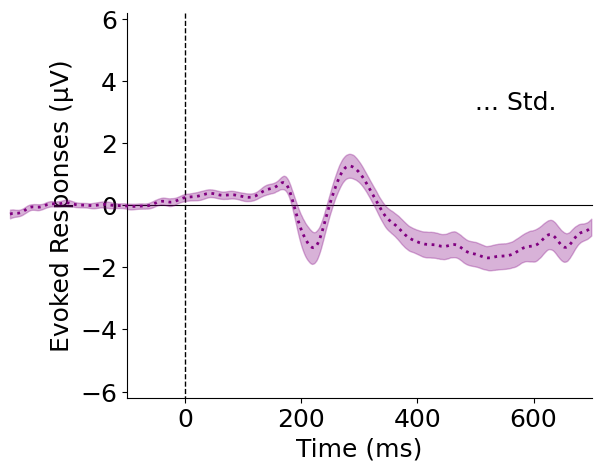

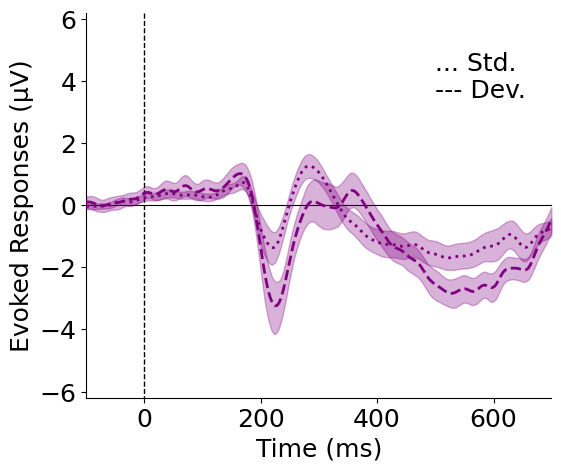

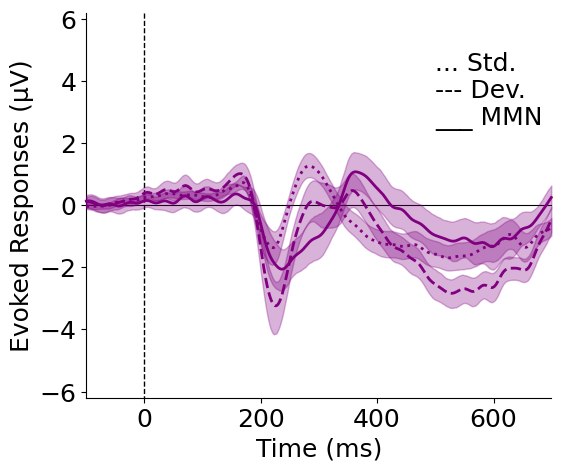

In [46]:
picks= ['F3', 'Cz', 'F4',]
# Define the start and end time for the window 
start_time = -0.1  # Start of time window in seconds
end_time = 0.6
# End of time window
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'Non PS std':B1_sta_eps_evoked_list,
           
           }

# Subset the evoked data by selecting the time range
"""


for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = [ evk.copy().crop(tmin=start_time, tmax=end_time) for evk in evokeds]
    evokeds_subset[key] = evoked_crop
"""
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',  
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
axs.set_xlim(-100, 700)
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps_evoked_list,
           'Non PS std':B1_sta_eps_evoked_list,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps_evoked_list,
           'Non PS std':B1_sta_eps_evoked_list,
           'Non PS MMN': non_sign_MMN_evokeds_list ,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"___ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size 
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

### Personal significNCE (smartphone notification )  MMN ERP

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().

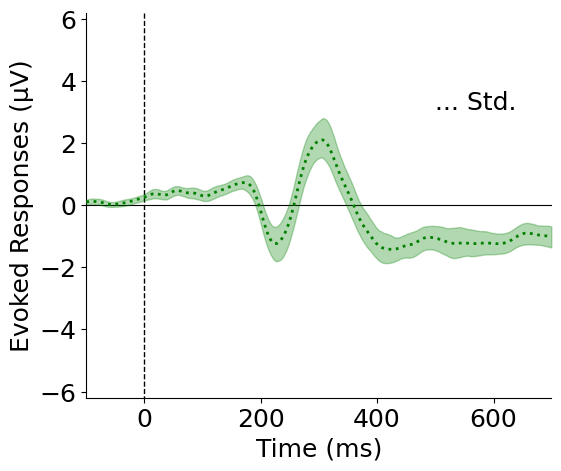

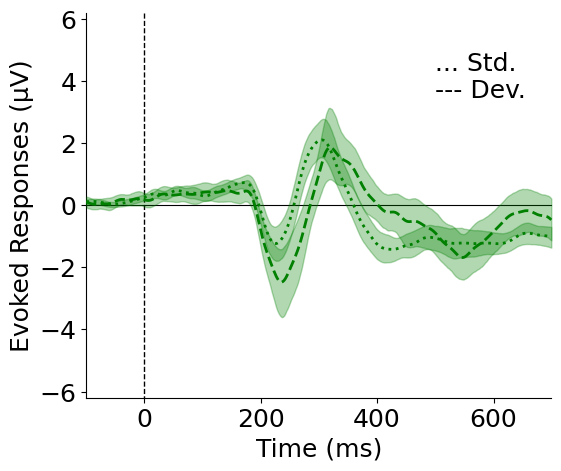

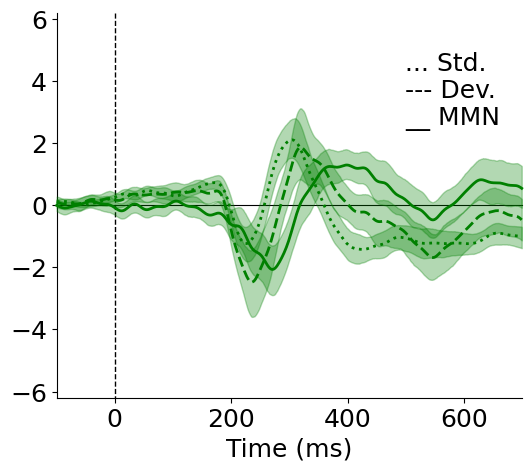

In [47]:
# ### Personalized siginificant ERP for all the categories
picks= ['F3', 'Cz', 'F4',]
evokeds = {
    'PS std':B2_sta_eps_evoked_list,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps_evoked_list,
           'PS std':B2_sta_eps_evoked_list,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps_evoked_list,
           'PS std':B2_sta_eps_evoked_list,
           'PS MMN': Personal_MMN_evokeds_list,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"__ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\3400616317.py:10: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\3400616317.py:10: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\3400616317.py:10: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21484\3400616317.py:10: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().

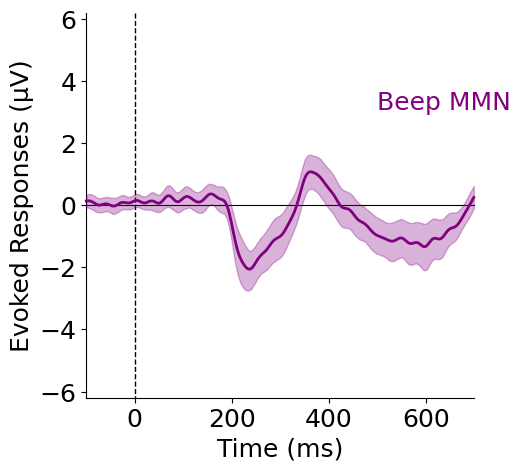

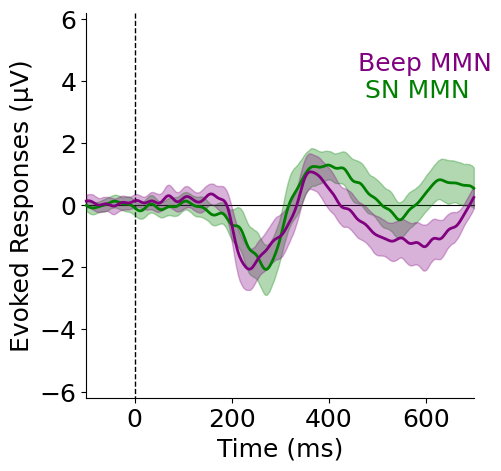

In [56]:

# ### Personalized siginificant ERP for all the categories
evokeds = {
    'NPS MMN':non_sign_MMN_evokeds_list,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(5, 5), dpi =100)

stylesdict ={
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid',},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='purple')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(5, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_evokeds_list,
    'NPS MMN':non_sign_MMN_evokeds_list,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.70,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.72,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
# Plot the evoked responses
plt.show()

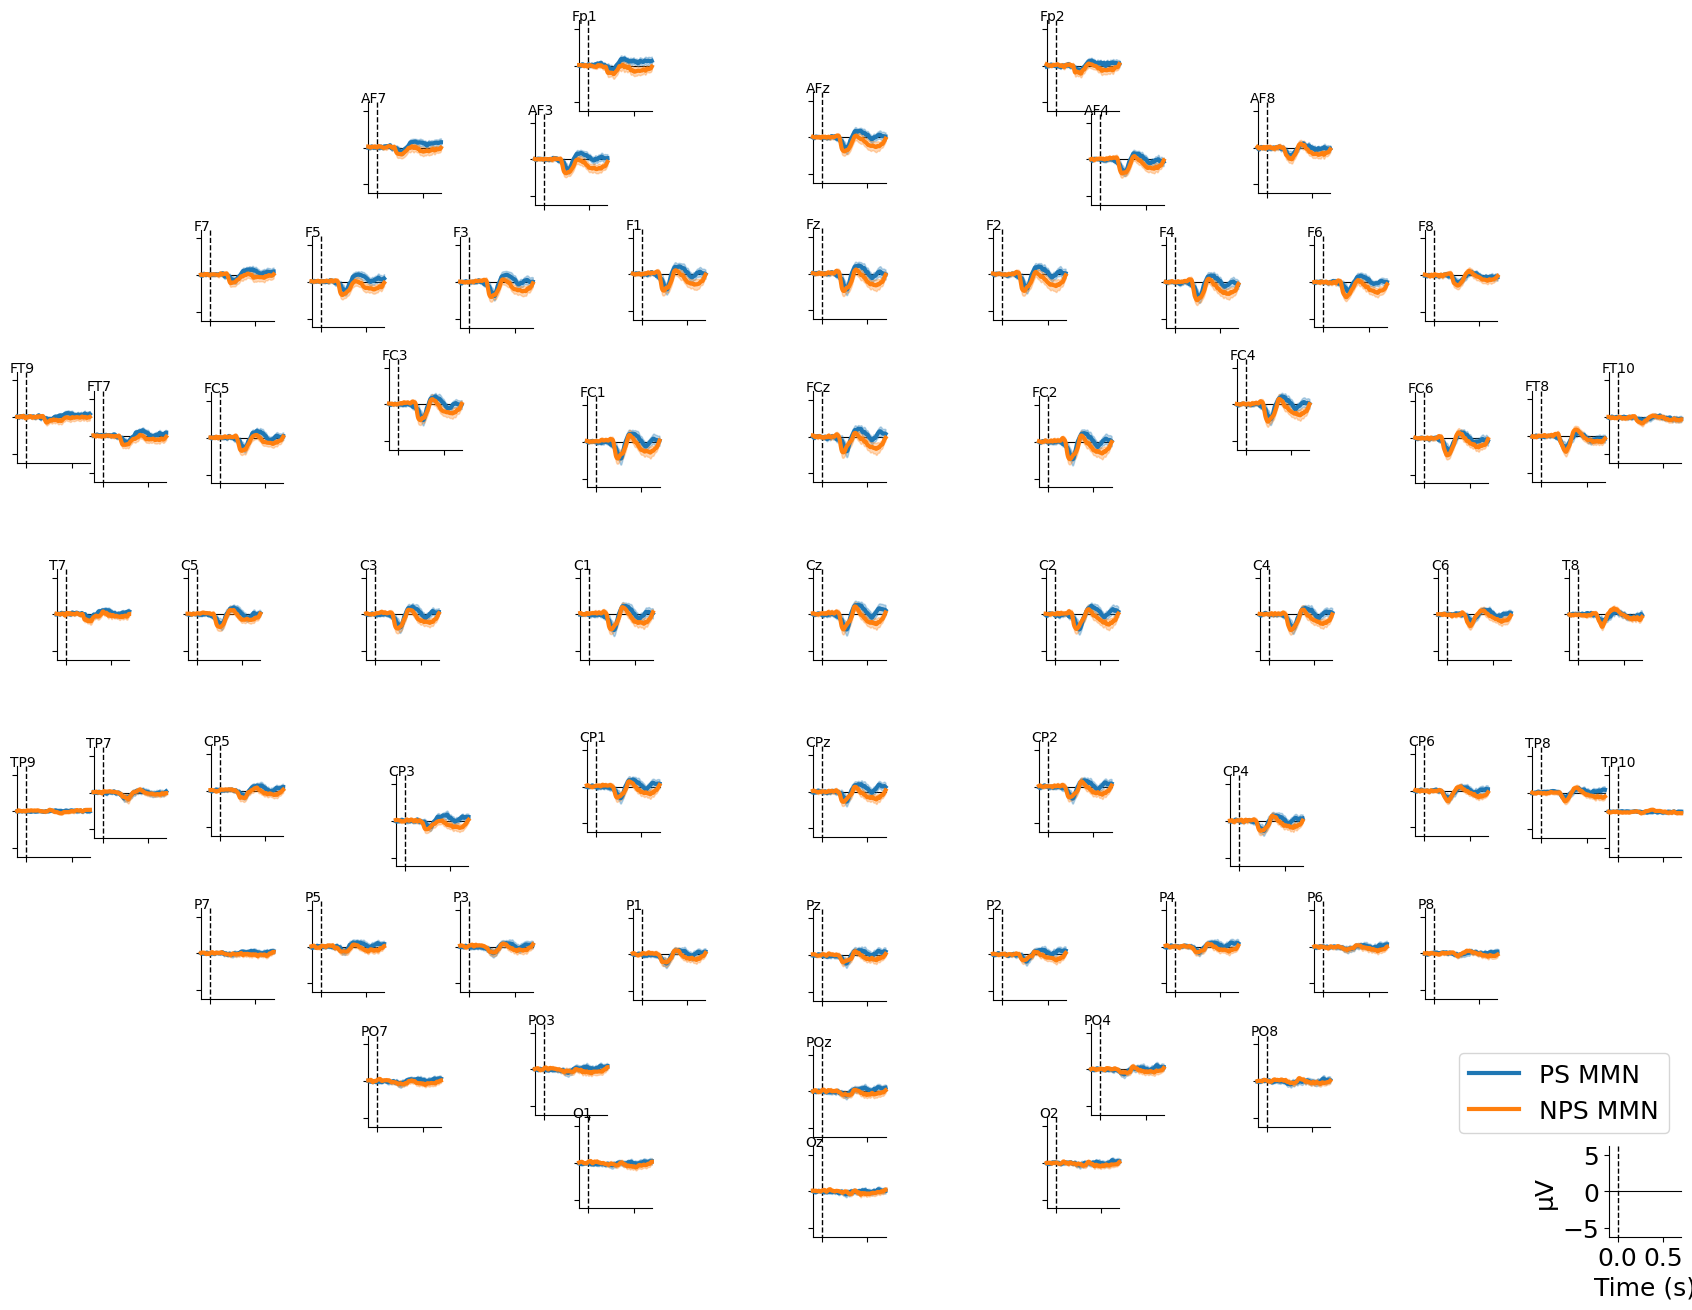

[<Figure size 1800x1400 with 65 Axes>]

In [50]:
stylesdict ={"PS MMN": {"linewidth": 3,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset,axes='topo',styles = stylesdict,
                             truncate_xaxis=False,truncate_yaxis=False,
                             ylim = dict(eeg=[-6.2,6.2]))


In [18]:
# """
# #import pandas as pd
# #che_info= pd.read_excel(r'C:\Users\PRAKASH\OneDrive - IIT Delhi\IIT D PhD\Research work\Smartphone addiction\EEG_electrode_naming_issue\New_ch_name.xlsx')
# dict(che_info[['Name','actual name']])

# chan_rename =dict(zip(che_info['Name'], che_info['actual name']))
# chan_rename = dict(list(chan_rename.items())[:-2])
# evkised = { "PS MMN":[],'NPS MMN' :[]}
# for evk in evokeds_subset['NPS MMN']:
#     evk.rename_channels(chan_rename )
#     evk.set_montage('easycap-M1' )
#     evkised['NPS MMN'].append(evk)
# for evk in evokeds_subset['PS MMN']:
#     evk.rename_channels(chan_rename )
#     evk.set_montage('easycap-M1' )
#     evkised['PS MMN'].append(evk)
# mne.viz.plot_compare_evokeds(evkised,axes='topo',styles = stylesdict,
#                              truncate_xaxis=False,truncate_yaxis=False,
#                              ylim = dict(eeg=[-6.2,6.2]))"""

In [19]:
print(mne.channels.get_builtin_montages())

['standard_1005', 'standard_1020', 'standard_alphabetic', 'standard_postfixed', 'standard_prefixed', 'standard_primed', 'biosemi16', 'biosemi32', 'biosemi64', 'biosemi128', 'biosemi160', 'biosemi256', 'easycap-M1', 'easycap-M10', 'easycap-M43', 'EGI_256', 'GSN-HydroCel-32', 'GSN-HydroCel-64_1.0', 'GSN-HydroCel-65_1.0', 'GSN-HydroCel-128', 'GSN-HydroCel-129', 'GSN-HydroCel-256', 'GSN-HydroCel-257', 'mgh60', 'mgh70', 'artinis-octamon', 'artinis-brite23', 'brainproducts-RNP-BA-128']


In [20]:
# """evkised['PS MMN'][0].set_montage('easycap-M1' )# Plot the evoked responses
# fig,axes = plt.subplots(1, 2, figsize=(15, 7),  sharey=True, dpi =300)


# evkised['PS MMN'][0].plot_sensors(show_names= True,show = False)

# axes[0].set_title('Evoked 1')

# # Plot sensors for the second Evoked
# evkised['PS MMN'][0].rename_channels(chan_rename )
# evkised['PS MMN'][0].plot_sensors(show_names= True,show = False)
# axes[1].set_title('Evoked 2')

# # Show the figure
# plt.show()"""

# Smartphone usage based group

In [21]:
import pandas as pd
subject_info= pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\ECF_smartphone_survey.xlsx")
subject_info.head()

,Timestamp,Email Address,Subject ID,Age,Gender,Occupation,Education,I can never spend enough time on my mobile phone.,I have used my mobile phone to make myself feel better when I was feeling down.,"I find myself occupied on my mobile phone when I should be doing other things, and it causes problems.",...,How did you feel about the notifications during the 2nd half of the experiment?,My phone is on [Silent / DND].1,My phone is on [Sometimes],My phone is on [Most of the times],My phone is on [Always],My phone is on [Vibrate only].1,My phone is on [Loud].1,Do you receive notifications on some other device instead (like a smartwatch)?,MPPUS,SAS
0,2024-05-15 11:36:03.174000,sgandhi@iitj.ac.in,sub002,NaN,NaN,NaN,NaN,3,7,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,50
1,2024-05-27 17:36:20.547000,tanvi.gandhi.ajmer@gmail.com,sub003,NaN,NaN,NaN,NaN,8,9,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176,130
2,2024-05-28 13:42:27.613000,rishabh1000khandelwal@gmail.com,sub004,NaN,NaN,NaN,NaN,5,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,124,107
3,2024-05-29 19:50:37.592000,m23air013@iitj.ac.in,sub005,NaN,NaN,NaN,NaN,2,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,106
4,2024-05-31 18:33:04.260000,anikde@iitj.ac.in,sub006,NaN,NaN,NaN,NaN,8,7,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107,60


In [22]:
subject_info["avg_S"] = subject_info[['MPPUS',	'SAS'	]].mean(axis=1)
#subject_info_D=subject_info[subject_info["Subject ID"].str.contains("SD")]
#subject_info_D
subject_info_D=subject_info.copy()
subject_info_D

,Timestamp,Email Address,Subject ID,Age,Gender,Occupation,Education,I can never spend enough time on my mobile phone.,I have used my mobile phone to make myself feel better when I was feeling down.,"I find myself occupied on my mobile phone when I should be doing other things, and it causes problems.",...,My phone is on [Silent / DND].1,My phone is on [Sometimes],My phone is on [Most of the times],My phone is on [Always],My phone is on [Vibrate only].1,My phone is on [Loud].1,Do you receive notifications on some other device instead (like a smartwatch)?,MPPUS,SAS,avg_S
0,2024-05-15 11:36:03.174000,sgandhi@iitj.ac.in,sub002,NaN,NaN,NaN,NaN,3,7,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,50,55.0
1,2024-05-27 17:36:20.547000,tanvi.gandhi.ajmer@gmail.com,sub003,NaN,NaN,NaN,NaN,8,9,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176,130,153.0
2,2024-05-28 13:42:27.613000,rishabh1000khandelwal@gmail.com,sub004,NaN,NaN,NaN,NaN,5,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,124,107,115.5
3,2024-05-29 19:50:37.592000,m23air013@iitj.ac.in,sub005,NaN,NaN,NaN,NaN,2,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,106,123.0
4,2024-05-31 18:33:04.260000,anikde@iitj.ac.in,sub006,NaN,NaN,NaN,NaN,8,7,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107,60,83.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,3/30/2025 18:08:46,ankitmathurmohammadi@gmail.com,SD057,NaN,NaN,NaN,NaN,6,8,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,101,120.5
340,3/30/2025 20:50:27,prataprajsingh6@gmail.com,Sd058,NaN,NaN,NaN,NaN,4,10,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,151,112,131.5
341,3/30/2025 23:17:51,NaN,SD059,NaN,NaN,NaN,NaN,3,9,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,191,154,172.5
342,2025-01-04 19:55:16,rahulenviitd@gmail.com,SD060,NaN,NaN,NaN,NaN,5,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147,98,122.5


Shapiro-Wilk Test for MPPUS: ShapiroResult(statistic=0.9934500846396134, pvalue=0.1412644922092764)
Shapiro-Wilk Test for SAS: ShapiroResult(statistic=0.9922694088617041, pvalue=0.07129202190783392)
Shapiro-Wilk Test for Avg: ShapiroResult(statistic=0.9905479442342819, pvalue=0.02611383220998405)


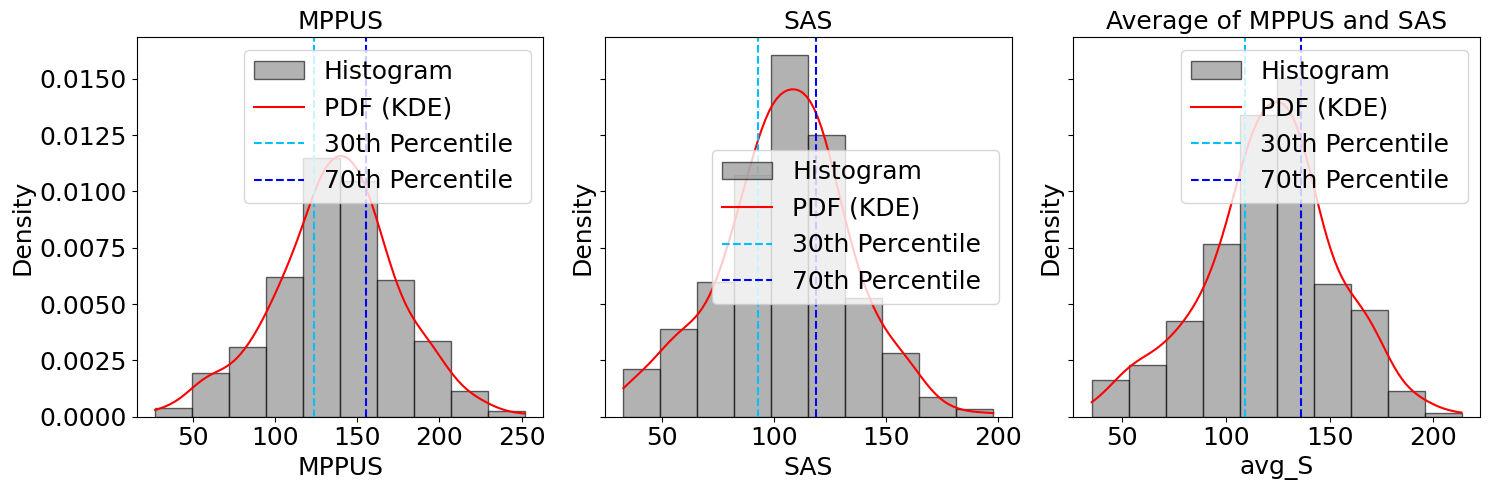

In [23]:
from scipy.stats import shapiro, kstest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
# Shapiro-Wilk test
shapiro_mppus = shapiro(subject_info_D['MPPUS'])
shapiro_sas = shapiro(subject_info_D['SAS'])
shapiro_avg_s = shapiro(subject_info_D['avg_S'])
print("Shapiro-Wilk Test for MPPUS:", shapiro_mppus)
print("Shapiro-Wilk Test for SAS:", shapiro_sas)
print("Shapiro-Wilk Test for Avg:", shapiro_avg_s )




# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
columns = ['MPPUS',	'SAS', 'avg_S']
titles = ['MPPUS', 'SAS', 'Average of MPPUS and SAS']

# Loop through columns to plot
for ax, column, title in zip(axes, columns, titles):
    # Data for the column
    data = subject_info_D[column]
    # Calculate quantiles
    q1 = subject_info_D[column].quantile(0.30)  # 25th percentil
    q3 = subject_info_D[column].quantile(0.70)  # 75th percentile
    # Plot histogram with density=True (normalized to PDF)
    ax.hist(data, bins=10, density=True, alpha=0.6, color='grey',edgecolor='black', label='Histogram')
    
    # Add Gaussian KDE for smooth curve
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_vals, kde(x_vals), color='red', label='PDF (KDE)')
    ax.axvline(q1, color='deepskyblue', linestyle='--', label='30th Percentile ')
    ax.axvline(q3, color='blue', linestyle='--', label='70th Percentile ')
    # Formatting
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import pearsonr

# Calculate correlation coefficient
corr_coeff, _ = pearsonr(subject_info_D['MPPUS'], subject_info_D['SAS'])
print(corr_coeff)

0.7904424291223553


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate 30th and 70th percentiles for SAS
sas_30 = subject_info_D['SAS'].quantile(0.30) 
sas_70 = subject_info_D['SAS'].quantile(0.70) 

# Create figure and axes

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =1000)  # Share y-axis for alignment
scatter_ax, hist_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(subject_info_D['SAS'] >= sas_70, 'darkorange', 
                  np.where(subject_info_D['SAS'] <= sas_30,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = subject_info_D['MPPUS'], y= subject_info_D['SAS'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": 70, "edgecolor": "black"},line_kws=dict(color="grey",alpha=0.8,linewidth = 3)  )

scatter_ax.text(0.75, 0.65, f"r = {corr_coeff:.2f}", transform=scatter_ax.transAxes, fontsize=20, color='black')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('SAS')
scatter_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
scatter_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')
# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label='HSU Group'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='LSU Group'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Avg. Smartphone User Group'),
], loc='upper left',handletextpad=0.2)
# === Second subplot: SAS Histogram === #
hist_ax.hist(subject_info_D['SAS'], bins=10, alpha=0.4,  color='grey',orientation='horizontal',edgecolor='black')

hist_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
hist_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')

hist_ax.set_xlabel('Count')
hist_ax.legend()
# Remove space between plots
for s,spine in enumerate(axes[0].spines.values()):
    if s !=0 and s != 2 :
        print(s,spine)
        spine.set_visible(False)
# Remove space between plots
for s,spine in enumerate(axes[1].spines.values()):
    if s !=2 :
        print(s,spine)
        spine.set_visible(False)
plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.rcParams.update({
    'xtick.labelsize': 15,  # X-axis tick labels font size
    'ytick.labelsize': 15,  # Y-axis tick labels font size
    'axes.labelsize': 15,   # Axis label font size
    'axes.titlesize': 15,   # Title font size
    'legend.fontsize': 15,   # Legend font size
})
plt.show()


1 Spine
3 Spine
0 Spine
1 Spine
3 Spine


0


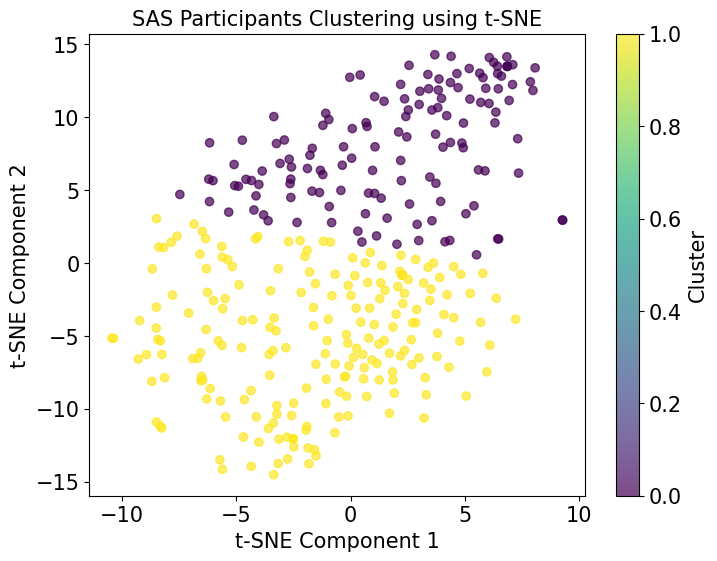

Silhouette Score: 0.47


In [26]:

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
df_selected = subject_info_D.iloc[:, 34:67]
df_selected
print(df_selected.isna().sum().sum())
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_selected), columns=df_selected.columns)



#  Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_standardized )

# Apply K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_tsne)

# Add cluster labels to the original dataframe
df_selected["Cluster"] = clusters

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("SAS Participants Clustering using t-SNE")
plt.colorbar(label="Cluster")
plt.show()

# Step 6: Evaluate clustering performance
silhouette_avg = silhouette_score(X_tsne, clusters)
print(f"Silhouette Score: {silhouette_avg:.2f}")


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


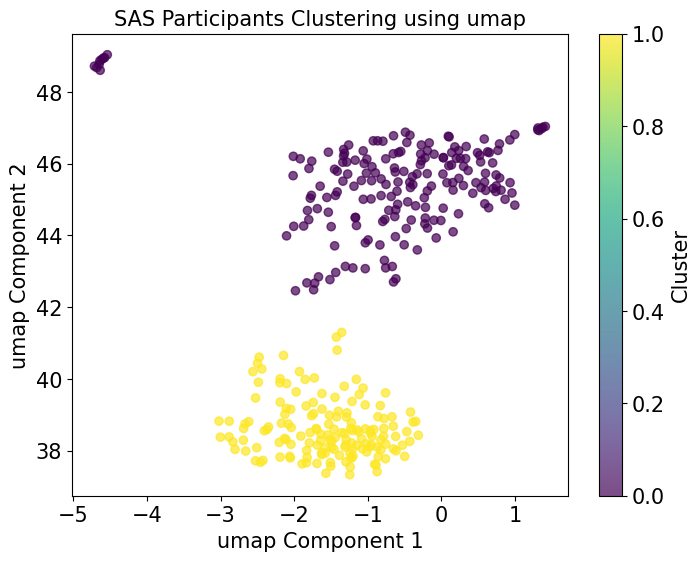

Silhouette Score: 0.24


In [27]:
import umap

umap_model = umap.UMAP(metric = 'chebyshev', random_state=42,n_epochs = 1000,min_dist = 0.1)
X_umap = umap_model.fit_transform(df_standardized)



# Apply K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_umap)


df_selected["Cluster"] = clusters

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.xlabel("umap Component 1")
plt.ylabel("umap Component 2")
plt.title("SAS Participants Clustering using umap")
plt.colorbar(label="Cluster") 
plt.show()

silhouette_avg = silhouette_score(X_tsne, clusters)
print(f"Silhouette Score: {silhouette_avg:.2f}")


In [28]:
subject_info_D['SAS_clus']=clusters
subject_info_D=subject_info_D[subject_info_D["Subject ID"].str.contains("SD")]

1 Spine
3 Spine


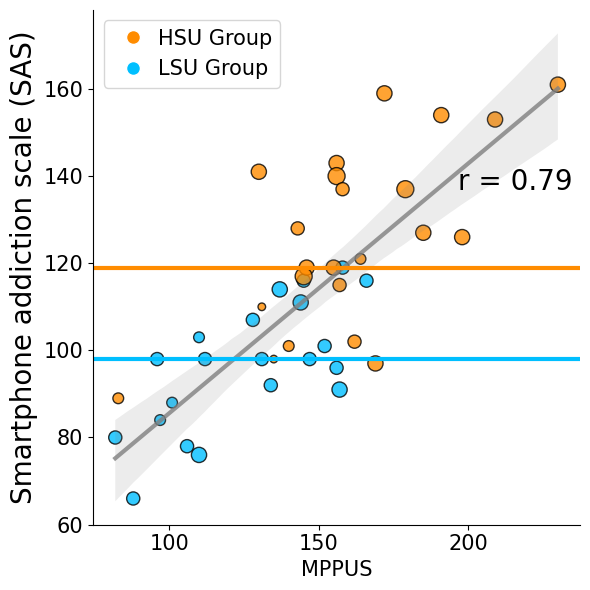

In [29]:
# Example mapping
response_map = {
    'Strongly disagree': 30,
    'Disagree': 60,
    'Neutral': 90,
    'Agree': 120,
    'Strongly agree': 150
}
sizes = subject_info_D['How much do you agree with the statement: I am addicted to my smartphone?'].map(response_map)





# Calculate 30th and 70th percentiles for SAS
sas_30 = subject_info_D['SAS'].quantile(0.30) 
sas_70 = subject_info_D['SAS'].quantile(0.70) 

# Create figure and axes

fig, axes = plt.subplots(1, 1, figsize=(6, 6),dpi =100)  # Share y-axis for alignment
scatter_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(subject_info_D['SAS_clus'] == 0 , 'darkorange', 
                  np.where(subject_info_D['SAS_clus'] == 1,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = subject_info_D['MPPUS'], y= subject_info_D['SAS'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": sizes, "edgecolor": "black"},line_kws=dict(color="grey",alpha=0.8,linewidth = 3)  )

scatter_ax.text(0.75, 0.65, f"r = {corr_coeff:.2f}", transform=scatter_ax.transAxes, fontsize=20, color='black')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('Smartphone addiction scale (SAS)',fontsize=20)
scatter_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
scatter_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')
# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label='HSU Group'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='LSU Group'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Avg. Smartphone User Group'),
], loc='upper left',handletextpad=0.2)

# === Second subplot: SAS Histogram === #
# Remove space between plots
for s,spine in enumerate(axes.spines.values()):
    if s !=0 and s != 2 : 
        print(s,spine)
        spine.set_visible(False)

plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()


In [30]:
# low samrtphone user 
subject_info_D_low = subject_info_D[subject_info_D['SAS_clus']==1]
# high smartphone user 
subject_info_D_high = subject_info_D[subject_info_D['SAS_clus']==0]
# catogory subject list 
low_sub_D = list(subject_info_D_low['Subject ID'])

high_sub_D = list(subject_info_D_high['Subject ID'])


### LSU and HSU MMN

In [67]:

B1_devi_eps_evoked_list_low = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub in low_sub_D]

B1_sta_eps_evoked_list_low = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub in low_sub_D]

B2_devi_eps_evoked_list_low =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub in low_sub_D]

B2_sta_eps_evoked_list_low = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub in low_sub_D]
  
Personal_MMN_evokeds_list_low = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B1_devi_eps_evoked_list_low, B2_sta_eps_evoked_list_low)
]



non_sign_MMN_evokeds_list_low = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B2_devi_eps_evoked_list_low, B1_sta_eps_evoked_list_low)
] 



In [ ]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_evokeds_list_low,
    'NPS MMN':non_sign_MMN_evokeds_list_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='LSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})

IndexError: list index out of range

In [35]:



B1_devi_eps_evoked_list_high = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub in high_sub_D]

B1_sta_eps_evoked_list_high = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub in high_sub_D]

B2_devi_eps_evoked_list_high =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub in high_sub_D]

B2_sta_eps_evoked_list_high = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub in high_sub_D]
  
Personal_MMN_evokeds_list_high = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B1_devi_eps_evoked_list_high, B2_sta_eps_evoked_list_high)
]



non_sign_MMN_evokeds_list_high = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B2_devi_eps_evoked_list_high, B1_sta_eps_evoked_list_high)
] 



In [36]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_evokeds_list_high,
    'NPS MMN':non_sign_MMN_evokeds_list_high,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 




stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='HSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})

IndexError: list index out of range

In [57]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'HSU': Personal_MMN_evokeds_list_high,
           'LSU': Personal_MMN_evokeds_list_low,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 

# Plot the evoked responses
fig,axs = plt.subplots(1, 2, figsize=(15, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =300)

stylesdict ={'HSU': {"linewidth": 3,"linestyle":'solid'},
             'LSU' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (SN)')



# ### Non Personalized siginificant ERP for all the categories
evokeds = {'HSU': non_sign_MMN_evokeds_list_high,
           'LSU': non_sign_MMN_evokeds_list_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (Beep tone)')


# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.80,  0.73,f"HSU", transform=axs[0].transAxes, fontsize=25, color='deepskyblue')
axs[0].text( 0.80,0.80, f"LSU", transform=axs[0].transAxes, fontsize=25, color='darkorange')

axs[1].text(0.80,0.73, f"HSU", transform=axs[1].transAxes, fontsize=25, color='deepskyblue')
axs[1].text( 0.80,0.80, f"LSU", transform=axs[1].transAxes, fontsize=25, color='darkorange')
# Add an overall title for the whole plot

# Add an arrow pointing to a specific point
"""axs[0].text(0.50, 0.05, f"N1", transform=axs[0].transAxes, fontsize=24, color='black')
axs[0].text( 0.62,0.8, f"P1", transform=axs[0].transAxes, fontsize=24, color='black')
# Add an arrow pointing to a specific point
axs[1].text(0.45, 0.05, f"N1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.58,0.60, f"P1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.75,0.68, f"P2", transform=axs[1].transAxes, fontsize=24, color='black')"""
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
axes[1].set_ylabel('Evoked Responses (µV)')
"""for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')"""
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()

IndexError: list index out of range

In [ ]:
# TOPO MAP with all electrodes 

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [.200, .250,.300,.350,.400, .45,.5,]

# Set the color scale range
vlim = (-3, 3)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(2, len(time_points), figsize=(12, 6), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(Personal_MMN_evokeds_list_high).copy().drop_channels([ "FC3"]).plot_topomap(
        times=[time], axes=axes[0, i], colorbar=False, vlim=vlim, show=False,contours = 0,
    )
    axes[0, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Plot topomaps for the second evoked (B1_MMN_erp)
for i, time in enumerate(time_points):
    im= mne.grand_average(Personal_MMN_evokeds_list_low).copy().drop_channels(["FC3"]).plot_topomap(
        times=[time], axes=axes[1, i], colorbar=False, vlim=vlim, show=False,contours = 0,
    ) 
    axes[1, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.99, 0.15, 0.02, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Amplitude (µV)')

# Add row labels
fig.text(0.0001, 0.75, 'HSU PS MMN', fontsize=15, rotation=90, va='center')
fig.text(0.0001, 0.25, 'LSU PS MMN', fontsize=15   , rotation=90, va='center')

plt.show()